<a href="https://colab.research.google.com/github/Amitabh-Phule/Reinforcement-Learning/blob/main/RL_Exp_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Title**
Monte Carlo Prediction and Control

## **Aim**
To estimate value functions using Monte Carlo methods and learn an optimal policy through episodic interaction.

## **Theory**
Monte Carlo methods are reinforcement learning methods that learn value functions from complete episodes of experience.

Unlike Dynamic Programming, Monte Carlo methods do not require the complete model of the environment.

A Monte Carlo method waits until an episode is completed and then uses the total return obtained from that episode to estimate the value of visited states.

The return Gt is calculated as:

Gt = Rt+1 + γRt+2 + γ²Rt+3 + ...

where:

Gt = Return from time t
Rt+1 = Reward received after time t
γ = Discount factor

In Monte Carlo Prediction, the value function is estimated for a given policy.

In Monte Carlo Control, the agent improves its policy by using the estimated action values.

In this experiment, Monte Carlo Prediction and Control are implemented using the Blackjack environment. The agent interacts with the environment through complete episodes and learns which actions produce better returns.

## **Algorithm**

1. Create the Blackjack environment.

2. Initialize the value function Q(s,a) for all state-action pairs.

3. Initialize the visit count for each state-action pair.

4. Initialize the policy using ε-greedy action selection.

5. Start a new episode.

6. Select actions according to the current ε-greedy policy.

7. Store every state, action, and reward obtained during the episode.

8. Continue until the episode terminates.

9. Calculate the return G for each visited state-action pair by moving backward through the episode.

10. Update the action-value function using the average of observed returns.

11. Improve the policy using the updated Q-values.

12. Repeat the process for many episodes.

13. Display the learned value function and policy.

14. Evaluate the learned policy using additional episodes.

## **Install and Import Required Libraries**

In [1]:
!pip install gymnasium -q

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

## **Create Blackjack Environment**

In [2]:
## **Create Blackjack Environment**

env = gym.make("Blackjack-v1")

print("Environment:", env.spec.id)
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

print("\nActions:")
print("0 = Stick")
print("1 = Hit")

Environment: Blackjack-v1
Observation Space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action Space: Discrete(2)

Actions:
0 = Stick
1 = Hit


## **Define ε-Greedy Policy**

In [3]:
## **Define ε-Greedy Policy**

epsilon = 0.1

def choose_action(Q, state):

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    q_values = Q[state]

    return int(np.argmax(q_values))

## **Initialize Monte Carlo Variables**

In [4]:
## **Initialize Monte Carlo Variables**

# Action-value function
Q = defaultdict(lambda: np.zeros(env.action_space.n))

# Number of returns observed for each state-action pair
returns_count = defaultdict(int)

# Number of training episodes
n_episodes = 50000

# Store episode rewards
episode_rewards = []

print("Number of training episodes:", n_episodes)
print("Epsilon:", epsilon)

Number of training episodes: 50000
Epsilon: 0.1


## **Monte Carlo Control Training**

In [5]:
## **Monte Carlo Control Training**

for episode in range(n_episodes):

    state, info = env.reset()

    episode_data = []
    done = False

    # Generate one complete episode
    while not done:

        action = choose_action(Q, state)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode_data.append(
            (state, action, reward)
        )

        state = next_state

        done = terminated or truncated

    # Calculate total reward
    total_reward = sum(
        reward
        for _, _, reward in episode_data
    )

    episode_rewards.append(total_reward)

    # First-visit Monte Carlo update
    G = 0
    visited = set()

    for state, action, reward in reversed(episode_data):

        G = reward + G

        state_action = (state, action)

        if state_action not in visited:

            visited.add(state_action)

            returns_count[state_action] += 1

            Q[state][action] += (
                G - Q[state][action]
            ) / returns_count[state_action]

print("Monte Carlo training completed.")

Monte Carlo training completed.


## **Extract Learned Policy**

In [7]:
## **Extract Learned Policy**

def get_best_action(state):
    return int(np.argmax(Q[state]))

print("Learned Policy:")

sample_states = list(Q.keys())[:10]

for state in sample_states:

    action = get_best_action(state)

    action_name = "Stick" if action == 0 else "Hit"

    print(
        f"State: {state} → {action_name}"
    )

Learned Policy:
State: (16, 3, 0) → Stick
State: (13, 3, 0) → Stick
State: (20, 10, 0) → Stick
State: (11, 10, 0) → Hit
State: (9, 2, 0) → Hit
State: (17, 7, 0) → Stick
State: (20, 2, 1) → Stick
State: (12, 2, 1) → Hit
State: (19, 10, 0) → Stick
State: (9, 9, 0) → Hit


## **Evaluate Learned Policy**

In [8]:
## **Evaluate Learned Policy**

def evaluate_policy(n_eval_episodes=5000):

    wins = 0
    losses = 0
    draws = 0
    total_reward = 0

    for _ in range(n_eval_episodes):

        state, info = env.reset()
        done = False

        while not done:

            action = get_best_action(state)

            next_state, reward, terminated, truncated, info = env.step(action)

            state = next_state
            done = terminated or truncated

        total_reward += reward

        if reward > 0:
            wins += 1
        elif reward < 0:
            losses += 1
        else:
            draws += 1

    return wins, losses, draws, total_reward


wins, losses, draws, total_reward = evaluate_policy()

print("========== POLICY EVALUATION ==========")
print("Wins:", wins)
print("Losses:", losses)
print("Draws:", draws)

print(
    "Win Percentage:",
    round(wins / 5000 * 100, 2),
    "%"
)

print(
    "Average Reward:",
    round(total_reward / 5000, 3)
)

========== POLICY EVALUATION ==========
Wins: 2130
Losses: 2483
Draws: 387
Win Percentage: 42.6 %
Average Reward: -0.071


## **Plot Episode Rewards**

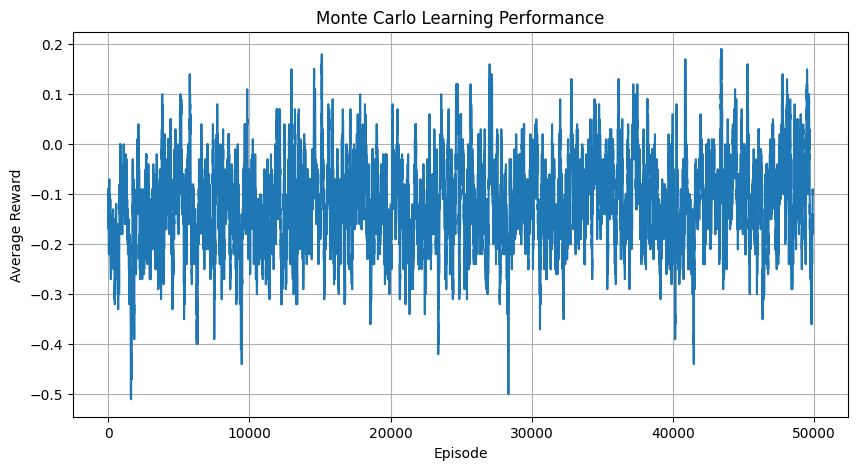

In [9]:
## **Plot Episode Rewards**

# Calculate moving average
window = 100

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Learning Performance")

plt.grid(True)
plt.show()

## **Display Learned Q-Values**

In [10]:
## **Display Learned Q-Values**

print("========== SAMPLE LEARNED Q-VALUES ==========")

count = 0

for state in Q:

    print(
        f"State: {state} | "
        f"Stick: {Q[state][0]:.3f} | "
        f"Hit: {Q[state][1]:.3f}"
    )

    count += 1

    if count >= 15:
        break

========== SAMPLE LEARNED Q-VALUES ==========
State: (16, 3, 0) | Stick: -0.295 | Hit: -0.857
State: (13, 3, 0) | Stick: -0.289 | Hit: -0.333
State: (20, 10, 0) | Stick: 0.431 | Hit: -0.886
State: (11, 10, 0) | Stick: -0.625 | Hit: -0.059
State: (9, 2, 0) | Stick: -0.242 | Hit: -0.143
State: (17, 7, 0) | Stick: -0.108 | Hit: -0.556
State: (20, 2, 1) | Stick: 0.701 | Hit: -1.000
State: (12, 2, 1) | Stick: -0.333 | Hit: 0.333
State: (19, 10, 0) | Stick: -0.042 | Hit: -0.710
State: (9, 9, 0) | Stick: -0.405 | Hit: 0.034
State: (10, 7, 0) | Stick: -0.600 | Hit: 0.223
State: (13, 10, 0) | Stick: -0.605 | Hit: -0.501
State: (17, 10, 0) | Stick: -0.411 | Hit: -0.727
State: (7, 10, 0) | Stick: -0.574 | Hit: -0.688
State: (20, 10, 1) | Stick: 0.460 | Hit: -0.278


## **Observation**

1. The Blackjack environment was successfully created.

2. The agent interacted with the environment through complete episodes.

3. State-action pairs and rewards were stored during each episode.

4. The return was calculated after an episode was completed.

5. The action-value function Q(s,a) was updated using Monte Carlo returns.

6. An ε-greedy strategy was used to balance exploration and exploitation.

7. The policy was improved using the learned Q-values.

8. After sufficient training, the agent learned different actions for different Blackjack states.

9. The learned policy was evaluated using additional episodes.

## **Conclusion**

Monte Carlo Prediction and Control were successfully implemented using the Blackjack environment.

The agent learned action values from complete episodes without requiring a model of the environment.

The experiment demonstrated how Monte Carlo methods can estimate value functions from experience and improve a policy using ε-greedy exploration.